# Preparing a nested simulation with CDR i: Parent simulation

In this tutorial, we will prepare and run a two-domain nested regional simulation with Ocean Alkalinity Enhancement, for two months. The domains are small enough to be run on a powerful laptop, but sufficient in scale as to show ROMS' capabilities for mCDR research. 

On this page, we prepare and run a parent simulation of Iceland and the Irminger Sea, which in turn produces boundary and initial conditions for a higher-resolution child simulation of northwest Iceland and the Denmark Strat in a nested subdomain. We will run the child simulation on the next page of the tutorial, including an alkalinity perturbation. Finally, to account for the anomalous alkalinity leaving the child domain, we run the parent domain a second time in the third step of this tutorial. This final simulation captures the flow of the perturbed alkalinity from the child domain into the larger parent domain using ROMS' upscaling capabilities.

## Requirements:
This tutorial requires an installation of ROMS and MARBL (see the installation pages of this documentation), as well as the `roms-tools` [python package](https://roms-tools.readthedocs.io/en/latest/). `roms-tools` additionally requires several datasets to prepare files for ROMS. See the `roms-tools` documentation for [information on obtaining these data](https://roms-tools.readthedocs.io/en/latest/datasets.html).

In [1]:
import os
os.chdir(f"{os.environ.get("ROMS_ROOT")}/Examples/Iceland/Iceland_parent")

In [2]:
%matplotlib inline
import roms_tools as rt
from pathlib import Path
import datetime as dt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


**After setting the next cell according to your own source data paths, the rest of the notebook should run:**

In [3]:
# ROMS tools source data:
rtd=Path("~/Code/roms_tools_datasets")

topo_path = rtd/"SRTM15_V2.5.nc" # Topography (SRTM15)
era5_path = [rtd/"ERA5_2012-01.nc", rtd/"ERA5_2012-02.nc"] # Surface forcing (ERA5)
bgc_path = rtd/"BGC/BGCdataset.nc" # BGC tracers for initial and boundary conditions (CWorthy unified BGC dataset)
bgc_surf_path = rtd/"BGC/BGCdataset.nc" # BGC surface forcing (CWorthy unified BGC dataset)
glorys_paths = [rtd/f"GLORYS/mercatorglorys12v1_gl12_mean_2012{m:02}{d:02}.nc" for m in range(1,3) for d in range(1,32)][:-2] # Interior state for initial and boundary conditions (GLORYS)
tpxo_path = rtd/"TPXO10.v2/" # Tidal forcing (TPXO)

## Simulation grid
We first set up the grid for the parent simulation using `roms-tools`, as well as defining related spatial parameters in our ROMS settings files. 

For more information on generating grids, see the corresponding `roms-tools` [documentation page](https://roms-tools.readthedocs.io/en/latest/grid.html).

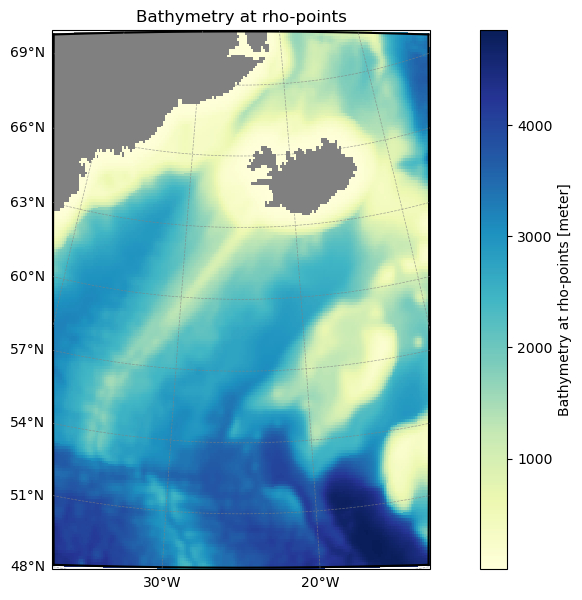

In [4]:
parent_grid = rt.Grid(
                        N=20,                       # Vertical levels
                        nx=192,                     # Points in x direction
                        ny=192,                     # Points in y direction
                        size_x=1750,                # Width of domain (km)
                        size_y=2500,                # Height of domain (km)
                        center_lon=-25,             # Center longitude
                        center_lat=60,              # Center latitude
                        rot=0,                      # Rotation
                        topography_source={         # Source topography data
                            "name": "SRTM15",
                            "path": str(topo_path),
                        }
                    )
parent_grid.plot()

In [5]:
# Save grid data
parent_grid_path    = parent_grid.save("input_data/iceland_parent_grid.nc")

2026-04-27 10:56:12 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_grid.nc


### Setting grid-related ROMS parameters
These are already set correctly for this domain in the included files in `$ROMS_ROOT/Examples/Iceland_parent`, but the relevant parameters are described here for reference:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `roms.in` | `THETA_S` | [Surface stretching parameter](https://roms-tools.readthedocs.io/en/latest/methods.html#vertical-coordinate-system)| 5.0* |
|   | `THETA_B` | [Bottom stretching parameter](https://roms-tools.readthedocs.io/en/latest/methods.html#vertical-coordinate-system) | 2.0* |
|   | `hc` | [critical depth](https://roms-tools.readthedocs.io/en/latest/methods.html#vertical-coordinate-system) | 300.0* |
|   | `grid: filename` | ROMS grid netcdf filepath | `input_data/iceland_parent_grid.nc` |

\* These are the default values set by `roms-tools`, and can be queried using `parent_grid.hc`, `parent_grid.theta_s`, and `parent_grid.theta_b` 

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `param.opt` | `LLm` | Number of gridpoints in x-direction | 192 |
|   | `MMm` | Number of gridpoints in y-direction | 192 |
|   | `N`   | Number of vertical levels | 20 |


## Simulation timing

In addition to the domain, the timing of the simulation is foundational to all of the other inputs. We need to provide `roms-tools` with start and end times that will cover all surface and boundary forcing files, and an initialization time, within that window, from which to begin the simulation. We must also set time-stepping parameters in ROMS.
We first set some local variables in this notebook to be used in `roms-tools`:

In [6]:
forcing_start_time = dt.datetime(2012,1,1,0,0,0)
forcing_end_time = dt.datetime(2012,3,1,0,0,0)
ini_time = dt.datetime(2012,1,1,12,0,0)

Here we have set the simulation to begin 12 hours after the beginning of the forcing time. _The simulation must always start at or after the beginning of the forcing._

### Setting timing-related ROMS parameters
We will run this simulation for 58 days (January + February) with a time-step of 900 seconds. This corresponds to 58*86400/900=5568 time-steps. These values are provided to ROMS via the runtime settings file `roms.in`. These are already set for this simulation in the included files in `$ROMS_ROOT/Examples/Iceland_parent`, but the relevant parameters are described here for reference:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `roms.in` | `NTIMES` | Number of time steps | 5568 |
|   | `dt` | time-step length in seconds | 900.0 |
|   | `NDTFAST` | Number of "fast" (barotropic) time-steps per time-step | 30 |

Other timing-related parameters such as model output frequency are described below under "Model output settings"

## Surface forcing
We will generate two surface forcing datasets using `roms-tools` (for more information on the process, see the [corresponding documentation](https://roms-tools.readthedocs.io/en/latest/surface_forcing.html)). The first is a bulk forcing input governing the variables impacting the physical circulation (10m wind velocity, short-wave radiation, 2m air temperature, precipitation, 2m humidity). The second covers variables impacting the biogeochemical equations (pCO2, iron deposition, dust deposition, and optionally - and not used by us for this simulation - nitrogen fluxes). These two forcing datasets are controlled within ROMS by parameters set in the `bulk_frc.opt` and `bgc.opt` files, respectively. We'll first generate and save these files, then take a look at these option files.

### Bulk forcing

In [7]:
# Physical surface forcing
parent_surface_bulk_forcing = rt.SurfaceForcing(
    grid = parent_grid,
    start_time= forcing_start_time,
    end_time= forcing_end_time,
    type= "physics",
    source={"name": "ERA5", "path": era5_path},
    use_dask=True,
)
# Save to netCDF
parent_surface_bulk_forcing_path = parent_surface_bulk_forcing.save("input_data/iceland_parent_surface_bulk_forcing.nc", group=False)


2026-04-27 10:56:13 - WARNING - No records found before the start_time: 2012-01-01 00:00:00.
2026-04-27 10:56:13 - WARNING - No records found after the end_time: 2012-03-01 00:00:00.
2026-04-27 10:56:14 - INFO - Data will be interpolated onto the fine grid. Remember to set `interp_frc = 0` in your `bulk_frc.opt` ROMS option file.
2026-04-27 10:58:22 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_surface_bulk_forcing.nc


[########################################] | 100% Completed | 237.10 s


Note the `INFO` message from `roms-tools`, reminding us to ensure consistency with the `bulk_frc.opt` file. The `interp_frc` setting signals to ROMS whether the surface forcing it reads is on the native model grid (`interp_frc=0`) or a lower-resolution (coarsened by a factor of 2) grid from which it will need to be interpolated (`interp_frc=1`). The latter can be more storage-efficient without impacting accuracy, particularly for higher resolution simulations, as we will see for our child domain. By default, `roms-tools` chooses the appropriate setting automatically based on the resolution of the grid and the forcing dataset. In this case, it has created surface forcing on the same grid as the model domain. 

Other than `interp_frc`, the other values in `bulk_frc.opt` tell ROMS which variables to look for amongst the forcing files to find the bulk forcing. `roms-tools` always produces forcing with the same variable names, so we don't need to change these. 

### Biogeochemical surface forcing


In [8]:
# BGC surface forcing
parent_bgc_surface_forcing = rt.SurfaceForcing(
    grid=parent_grid,
    start_time = forcing_start_time,
    end_time = forcing_end_time,
    source={"name": "UNIFIED", "path": bgc_surf_path, "climatology":True},
    type="bgc",
    use_dask=True,
)
parent_bgc_surface_forcing_path = parent_bgc_surface_forcing.save("input_data/iceland_parent_bgc_surface_forcing.nc", group=False)


2026-04-27 11:02:48 - WARNING - Optional variables missing (but not critical): ['pco2_air_alt']
2026-04-27 11:02:48 - INFO - Data will be interpolated onto the grid coarsened by factor 2. Remember to set `interp_frc = 1` in your `bgc.opt` ROMS option file.
2026-04-27 11:02:48 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_bgc_surface_forcing.nc


[########################################] | 100% Completed | 321.11 ms


Here we see that ROMS tools _has_ automatically interpolated the lower-resolution BGC forcing to a more storage efficient grid and is reminding us to set the value of `interp_frc` in the ROMS option file `bgc.opt` accordingly. As with `bulk_frc.opt`, the other settings in this file describe to ROMS the names of forcing-related variables, which are always the same when produced by `roms-tools`, and so don't need to be changed here.

## Boundary forcing
Similarly to the surface forcing, we will separately generate forcing at the boundaries of our domain for physics (covering state variables temperature, salinity, SSH, horizontal velocity) and biogeochemistry (covering the values of all biogeochemical tracers). We will use `roms-tools` to generate the former from the GLORYs reanalysis and the latter from \[C\]Worthy's [unified BGC dataset](https://roms-tools.readthedocs.io/en/latest/datasets.html#Downloading-the-Unified-BGC-Dataset):

In [9]:
parent_phys_boundary_forcing = rt.BoundaryForcing(
    grid=parent_grid,
    start_time = forcing_start_time,
    end_time = forcing_end_time,
    source={"name": "GLORYS", "path": glorys_paths},
    type="physics",  # "physics" or "bgc"; default is "physics"
    use_dask=True,
)

parent_bgc_boundary_forcing = rt.BoundaryForcing(
    grid=parent_grid,
    start_time = forcing_start_time,
    end_time = forcing_end_time,
    source={"name": "UNIFIED", "path": bgc_path, "climatology": True},
    type="bgc",
    use_dask=True,
)

parent_phys_boundary_forcing_path = parent_phys_boundary_forcing.save("input_data/iceland_parent_phys_boundary_forcing.nc",group=False)
parent_bgc_boundary_forcing_path  = parent_bgc_boundary_forcing.save("input_data/iceland_parent_bgc_boundary_forcing.nc",group=False)

2026-04-27 11:02:48 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-04-27 11:02:49 - WARNING - No records found before the start_time: 2012-01-01 00:00:00.
2026-04-27 11:02:49 - WARNING - No records found after the end_time: 2012-03-01 00:00:00.
2026-04-27 11:02:50 - WARNING - The northern boundary is divided by land. It would be safer (but slower and more memory-intensive) to use `apply_2d_horizontal_fill = True`.
2026-04-27 11:02:50 - WARNING - The western boundary is divided by land. It would be safer (but slower and more memory-intensive) to use `apply_2d_horizontal_fill = True`.
2026-04-27 11:02:52 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-04-27 11:02:52 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-04-27 11:02:56 - INFO - Writing the following NetCDF files:
input_da

[########################################] | 100% Completed | 36.47 s


2026-04-27 11:03:34 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_bgc_boundary_forcing.nc
/Users/dafyddstephenson/Code/roms-tools/roms_tools/utils.py:916: UserWarning: Unlimited dimension(s) {'time'} declared in 'dataset.encoding', but not part of current dataset dimensions. Consider removing {'time'} from 'dataset.encoding'.
  xr.save_mfdataset(dataset_list, output_filenames)


[########################################] | 100% Completed | 6.21 sms


For more information on generating boundary forcing with `roms-tools`, see [its documentation](https://roms-tools.readthedocs.io/en/latest/boundary_forcing.html). There are no user-controlled parameters concerning boundary forcing in ROMS, so we can move on.

## River Forcing
For any domain including a coastline, we can include riverine inputs at river mouths. Generally this input contains varying volume fluxes and constant tracer values that influence the physical and biogeochemical state in the neighboring ocean cells. `roms-tools` automatically detects rivers from the Dai and Trenberth dataset:

2026-04-27 11:03:41 - INFO - No river indices provided. Identify all rivers within the ROMS domain and assign each of them to the nearest coastal point.
2026-04-27 11:03:42 - INFO - Compute climatology for river forcing.
2026-04-27 11:03:43 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_river_forcing.nc


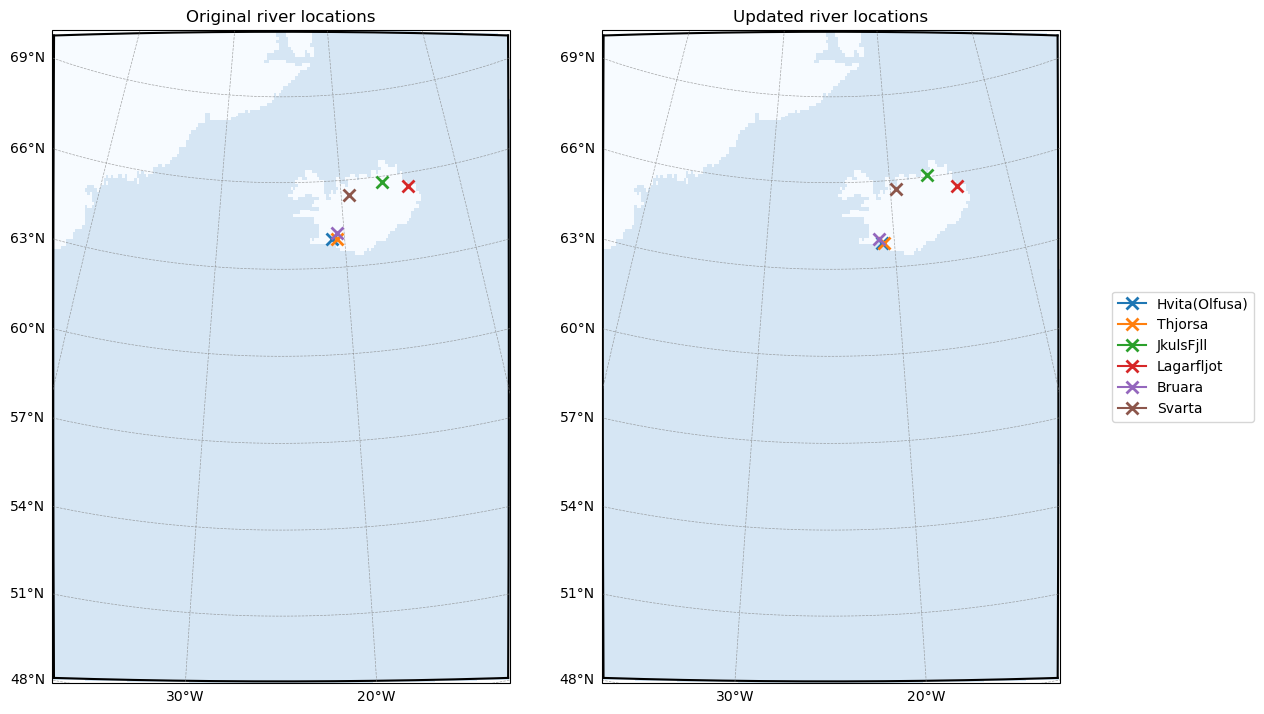

In [10]:
parent_river_forcing = rt.RiverForcing(
    grid=parent_grid,
    start_time = forcing_start_time,
    end_time = forcing_end_time,
    include_bgc = True,
)
parent_river_forcing.plot_locations()
parent_river_forcing_path = parent_river_forcing.save("input_data/iceland_parent_river_forcing.nc")

All that is left to do is tell ROMS to look for river inputs, and how many rivers to expect. We can query this in `roms-tools` via the underlying dataset (`.ds`) using `parent_river_forcing.ds.nriver`:

In [11]:
parent_river_forcing.ds.nriver

<xarray.DataArray 'nriver' (nriver: 6)> Size: 48B
array([1, 2, 3, 4, 5, 6])
Coordinates:
  * nriver      (nriver) int64 48B 1 2 3 4 5 6
    river_name  (nriver) object 48B 'Hvita(Olfusa)' 'Thjorsa' ... 'Svarta'
Attributes:
    long_name:  River ID (1-based Fortran indexing)

These parameters are set in the `river_frc.opt` file:


| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `river_frc.opt` | `river_source` | Whether ROMS should read river forcing for this simulation | `.true.` |
|                 | `nriv` | Number of rivers | 6 |

The other relevant settings in this file, as with surface and boundary forcing, concern variable names in the forcing data. As before, we do not need to change these as they are already set according to the naming rules in `roms-tools`. For more information on generating river forcing with `roms-tools`, see the [relevant documentation](https://roms-tools.readthedocs.io/en/latest/river_forcing.html).

## Tidal Forcing
The final forcing we will configure influences the tides in the model. `roms-tools` uses the TPXO product to generate roms-compatible tidal forcing:

[########################################] | 100% Completed | 430.67 ms


2026-04-27 11:04:14 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_tides.nc


[########################################] | 100% Completed | 18.81 s


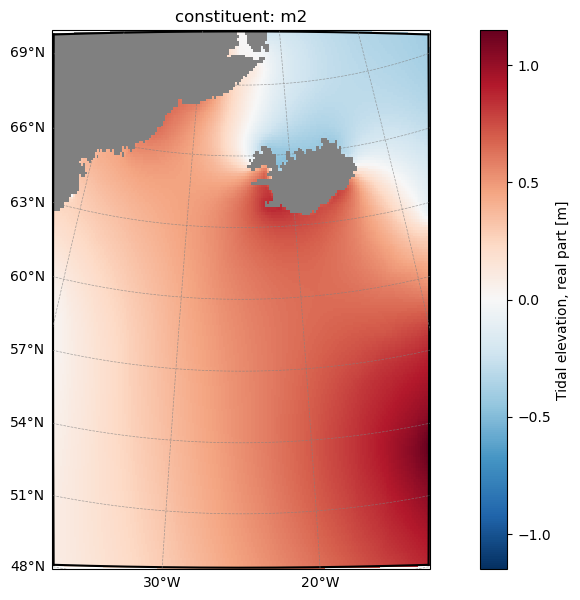

In [12]:
tpxo_path = rtd/"TPXO10.v2/"

parent_tidal_forcing = rt.TidalForcing(
    grid=parent_grid,
    source={"name": "TPXO", "path": 
                {
                "grid": tpxo_path / "grid_tpxo10v2.nc",
                "h": tpxo_path / "h_tpxo10.v2.nc",
                "u": tpxo_path / "u_tpxo10.v2.nc",
                }
           },
    ntides=10,
    use_dask=True
)
parent_tidal_forcing.plot("ssh_Re", ntides=0)
parent_tidal_forcing_path = parent_tidal_forcing.save("input_data/iceland_parent_tides.nc")


The relevant settings for ROMS can be found in `tides.opt`:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `tides.opt` | `ntides` | The number of tidal constituents in the forcing file | 10 |
|                 | `pot_tides` | Whether to force with surface tidal potential | .true. |
|                 | `bry_tides` | Whether to apply barotropic tidal forcing at the boundaries| .false. |


## Specifying forcing file locations to ROMS
This is done in the `roms.in` file under `forcing`:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `roms.in` | `forcing: filename` | Forcing file list | `input_data/iceland_parent_grid.nc` <br> `input_data/iceland_parent_surface_bulk_forcing.nc` <br> `input_data/iceland_parent_bgc_surface_forcing.nc` <br> `input_data/iceland_parent_phys_boundary_forcing.nc` <br> `input_data/iceland_parent_bgc_boundary_forcing.nc` <br> `input_data/iceland_parent_river_forcing.nc` <br> `input_data/iceland_parent_tides.nc` <br> `input_data/iceland_parent_initial_conditions.nc` <br> `input_data/iceland_child_grid_nesting_info.nc` |

Note that ROMS does not discern between different files (e.g. tidal, river forcing, etc.) as we have done here - it opens all the files listed here and searches them for the necessary forcing variables.

## Initial Conditions
Finally we generate initial conditions for the simulation. Unlike the surface and boundary forcing, the intitial conditions file contains all the information necessary about the model state, combining both physics and BGC variables. The `roms-tools` documentation is [here](https://roms-tools.readthedocs.io/en/latest/initial_conditions.html). As with the boundary conditions, we use GLORYs for the physics and \[C\]Worthy's [unified BGC dataset](https://roms-tools.readthedocs.io/en/latest/datasets.html#Downloading-the-Unified-BGC-Dataset):

In [13]:
parent_initial_conditions = rt.InitialConditions(
    grid = parent_grid,
    ini_time = ini_time,
    source={"name": "GLORYS", "path": glorys_paths[0]},
    bgc_source = {
        "name": "UNIFIED",
        "path": bgc_path,
        "climatology": True,
        },
    use_dask = True,
)

parent_initial_conditions_path = parent_initial_conditions.save("input_data/iceland_parent_initial_conditions.nc")


2026-04-27 11:04:36 - WARNING - Optional variables missing (but not critical): ['Lig', 'DIC_ALT_CO2', 'Alk_ALT_CO2']
2026-04-27 11:04:37 - INFO - Writing the following NetCDF files:
input_data/iceland_parent_initial_conditions.nc


[########################################] | 100% Completed | 4.12 sms


The location of the initial conditions file is provided to ROMS via the `roms.in` file under the `initial` header:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `roms.in` | `initial: NRREC` | Number of entries in the initial conditions file (1 for a clean start, 2 for a restart) | `1` |
| `roms.in` | `initial: filename` | Path to the initial conditions file | `input_data/iceland_parent_initial_conditions.nc` |


## Preparing for a nested simulation
As we intend for this simulation to generate boundary forcing and initial conditions for a nested subdomain, we must tell ROMS where that subdomain is, so we generate the grid for our child simulation now, and save information about the nesting relationship using `roms-tools`' `save_nesting` function:

In [14]:
child_grid = rt.Grid(
                        N=20,                       # Vertical levels
                        nx=192,                     # Points in x direction
                        ny=192,                     # Points in y direction
                        size_x=400,                 # Width of domain (km)
                        size_y=400,                 # Height of domain (km)
                        center_lon=-25,             # Center longitude
                        center_lat=65.5,            # Center latitude
                        rot=10,                     # Rotation
                        topography_source={         # Source topography data
                            "name": "SRTM15",
                            "path": str(topo_path),
                        }
                    )

We now "align" the parent and child grids, ensuring compatibility in a nested configuration:

In [15]:
child_grid = rt.align_grids(parent_grid=parent_grid, child_grid=child_grid, verbose=True)

2026-04-27 11:04:42 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-04-27 11:04:43 - INFO - === Modifying the child mask ===
2026-04-27 11:04:43 - INFO - Total time: 0.148 seconds
2026-04-27 11:04:43 - INFO - ================================================================================================
2026-04-27 11:04:43 - INFO - === Modifying the child topography ===
2026-04-27 11:04:44 - INFO - Total time: 0.147 seconds
2026-04-27 11:04:44 - INFO - ================================================================================================


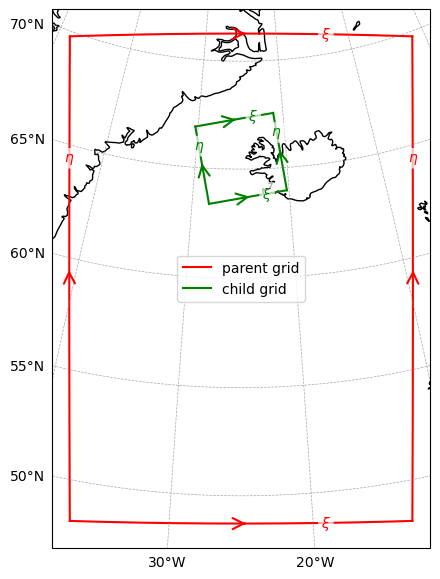

In [16]:
rt.plot_nesting(parent_grid, child_grid, with_dim_names=True)

### Save nesting information and child grid file
We need to provide ROMS with nesting information (describing the relationship between parent and child) to run the parent and generate boundary conditions for the child. This is another netCDF file:

In [17]:
nesting_info = rt.make_nesting_info(parent_grid=parent_grid, 
                               child_grid=child_grid, 
                               filepath="input_data/iceland_child_grid_nesting_info.nc", 
                               period=3600, 
                               include_bgc=True, 
                               include_pressure_fluxes=False, 
                               verbose=True)

2026-04-27 11:04:44 - INFO - No `boundaries` provided. Using mask-based defaults: {'south': True, 'east': True, 'north': True, 'west': True}
2026-04-27 11:04:44 - INFO - === Mapping the child grid boundary points onto the indices of the parent grid ===
2026-04-27 11:04:48 - INFO - Total time: 3.851 seconds
2026-04-27 11:04:48 - INFO - ================================================================================================
2026-04-27 11:04:48 - INFO - Writing the following NetCDF files:
input_data/iceland_child_grid_nesting_info.nc


Here `period` is the frequency we wish to write boundary forcing for the child simulation, `include_bgc` determines whether to include BGC tracer fluxes in the boundary forcing, and `include_pressure_fluxes` determines whether to include baraoclinic pressure fluxes in the boundary forcing.

We don't yet need the child grid itself, but as we have already created it, we can save it for re-use in the next tutorial:

In [18]:
child_grid.save("../Iceland_child/input_data/iceland_child_grid.nc")

2026-04-27 11:04:48 - INFO - Writing the following NetCDF files:
../Iceland_child/input_data/iceland_child_grid.nc


[PosixPath('../Iceland_child/input_data/iceland_child_grid.nc')]

It is not necessary to generate any other input files for the child simulation yet (that will follow on the next page of the tutorial). We must still configure ROMS to generate the child domain boundary forcing files, via the `extract_data.opt` options file:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `extract_data.opt` | `do_extract` | Tells ROMS whether to extract child domain boundary forcing during this simulation | `.true.` |
|                 | `extract_file` | Path to the nesting information we saved with `roms-tools` | `input_data/iceland_child_grid_nesting_info.nc` |
|                 | `extract_period` | Time period between data extraction (s) | `1800.0` |
|                 | `nrpf_ext` | Number of records in the extracted data file before beginning a new file | `48` |
|                 | `N_chd` | Number of vertical levels | 20 |
|                 | `theta_s_chd` | as with `THETA_S` above, for the child grid | 5.0 |
|                 | `theta_s_chd` | as with `THETA_B` above, for the child grid | 2.0 |
|                 | `hc_chd`      | as with `hc` above, for the child grid | 300.0 |

Lastly, it is necessary to tell the model to compute baroclinic pressure fluxes in order to generate complete boundary conditions. This is currently controlled via the `diagnostics` module's option file `diagnostics.opt`:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `diagnostics.opt` | `diag_pflx` | Tells ROMS whether to calculate baroclinic pressure fluxes during this simulation | `.true.` |

## Model output settings
There are three modules with option files of interest to us:
- `ocean_vars.opt` controls parameters concerning general output of the prognostic state variables, including restart files, which allow us to start the model back up and continue a simulation from a checkpoint
- `bgc.opt` controls parameters concerning general output of biogeochemical tracers and diagnostics
- `cdr_output.opt` controls parameters concerning specific output tailored to mCDR experiments. We won't use this output here, but in the child simulation, where we will include an mCDR intervention.

Here is how we set each:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `ocean_vars.opt` | `wrt_file_rst` | Tells ROMS whether to  write restart files | `.true.` |
|                  | `monthly_restarts` | If `true`, writes restart files at the beginning of each _calendar_ month | `.true.` |
|                  |  `output_period_rst` | Frequency of restart file creation (s), ignored if `monthly_restarts = .true.`| `86400.0` (ignored) |
|                  | `wrt_file_his` | Tells ROMS whether to  write ocean "history" files (snapshots of the model state) | `.false.` |
|                  | `output_period_his` | Frequency of history file creation (s) | `86400.0` (ignored) |
|                  |  `nprf_his` | Number of records in each history file before beginning a new file | `31` |
|                  | `wrt_file_avg` | Tells ROMS whether to  write ocean average files (time averages of the model state) | `.false.` |
|                  | `output_period_avg` | Frequency of file creation / averaging period (s) | `86400.0` (ignored) |
|                  | `nprf_avg` | Number of records in each average file before beginning a new file | `31` |
|    `bgc.opt`     | `wrt_his` | Tells ROMS whether to  write BGC "history" files (snapshots of BGC tracers) | `.true.` |
|                  | `output_period_his` | Frequency of history file creation (s) | `86400.0` (daily) |
|                  | `nprf_his` | Number of records in each history file before beginning a new file | `31` |
|                  | `wrt_avg` | Tells ROMS whether to  write BGC average files (time averages of BGC tracers) | `.false.` |
|                  | `output_period_avg` | Frequency of file creation / averaging period (s) | `86400.0` (ignored) |
|                  | `nprf_avg` | Number of records in each average file before beginning a new file | `31` |
|                  | `wrt_his_dia` | Tells ROMS whether to  write BGC diagnostic "history" files (snapshots of BGC diagnostics*) |`.false.`|
|                  | `output_period_his_dia` | Frequency of history file creation (s) | `86400.0` (ignored) |
|                  | `nprf_his_dia` | Number of records in each history file before beginning a new file | `31` |
|                  | `wrt_avg_dia` | Tells ROMS whether to  write BGC average files (time averages of BGC diagnostics) | `.false.` |
|                  | `output_period_avg_dia` | Frequency of file creation / averaging period (s) | `86400.0` (daily) |
|                  | `nprf_avg_dia` | Number of records in each average file before beginning a new file | `31` |

We can also set the target directory of the output and the filename prefix in `roms.in`:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `roms.in` | `output_root_name` | Tells ROMS where to save outputs and how to name them | `output_run1/iceland_parent` |

\* MARBL produces hundreds of BGC diagnostic fields in addition to its array of BGC tracers. These can be queried by running `requested_diags.py` in the directory `$MARBL_ROOT/tests/regression_tests/requested_diags/`, using the argument `-s marbl_in`. Here `marbl_in` is the settings file read by ROMS at runtime. The specific diagnostics calculated by MARBL depend on the chosen settings. The settings included in this example's `marbl_in` file can be taken as a default set, though advanced users may want to change them.

## Final ROMS preparation steps (pre-processing and compilation)
Now that we have prepared our input data, we can pre-process the input files for use in ROMS and compile the model. 

### Pre-processing (input data partitioning)
Necessary pre-processing involves "partitioning" the files so that the model can run with multiple processors in parallel - each processor gets a subset of the grid points to operate on, so we must split up the input files we've generated accordingly. ROMS provides a tool to accomplish this: `partit`.

For this example, we are going to run the model using 9 processors. There are of course multiple ways to split a 2D grid in 9, but we will allow for 3 processors in each direction. The call to partit is therefore `partit 3 3 <input_file.nc>`:

In [ ]:
%%bash
cd input_data/
partit 3 3 iceland_parent_grid.nc
partit 3 3 iceland_child_grid_nesting_info.nc
partit 3 3 iceland_parent_initial_conditions.nc
partit 3 3 iceland_parent_surface_bulk_forcing.nc
partit 3 3 iceland_parent_bgc_surface_forcing.nc
partit 3 3 iceland_parent_phys_boundary_forcing.nc
partit 3 3 iceland_parent_bgc_boundary_forcing.nc
partit 3 3 iceland_parent_river_forcing.nc
partit 3 3 iceland_parent_tides.nc


_(Cell output hidden due to length)_

We also have to tell ROMS how we have partitioned the input files. This is done via `param.opt`, with the other domain-related parameters we set above:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `param.opt` | `NP_XI` | Number of parallel subdomains in the x-direction | `3` |
|             | `NP_ETA`| Number of parallel subdomains in the y-direction | `3` |

### Compiling the model
The first time we run a simulation, or any time after when we change a parameter in a `.opt` file, we need to compile the model. This is done via a call to `make` in the same directory as our `.opt` files. We also require a `Makefile`. This is included here, but is stored in the `Work` directory at the repository top level if it is needed again:

In [ ]:
%%bash
make compile_clean
make

_(Cell output hidden due to length)_

## Running the simulation
Our simulation uses 9 processors, so we run the executable we just compiled using `mpirun -n 9 ./roms roms.in` where `roms` is the executable we just compiled and `roms.in` is the runtime settings file. Note that on HPC systems, this call may differ from `mpirun` (e.g. `mpiexec`, `srun`), and may need to be wrapped in a job scheduler submission script.

In [ ]:
%%bash
mpirun -n 9 ./roms roms.in

_(Cell output hidden due to length)_

## Model output and post-processing
As set above, files produced by ROMS during the run are in the `output` directory. The general file naming pattern of ROMS output is:

`<output_directory_path>/<filename_prefix>_<output_type>.<date of first output>.<processor>.nc`

Based on the settings discussed above, `<output_type>` here can be one of:

| Output type    | Description   |
| -------------- | ------------- |
| `_his`         | Ocean physics variables (dynamic tracers, velocity fields), instantaneous output          |
| `_avg`         | Ocean physics variables (dynamic tracers, velocity fields), time-averaged output          |
| `_rst`         | ROMS restart file (full model state for exact restart)                                    |
| `_bgc`         | Ocean biogeochemical tracers, instantaneous output                                        |
| `_bgc_avg`     | Ocean biogeochemical tracers, time-averaged output                                        |
| `_bgc_dia`     | Ocean biogeochemical diagnostic fields, instantaneous output                              |
| `_bgc_dia_avg` | Ocean biogeochemical diagnostic fields, time-averaged output                              |
| `_ext`         | "extraction" files, which form the basis for boundary forcing for the nested/child domain |

For example, let's take a look at all the BGC tracer output files:

In [22]:
%%bash
ls output/*_bgc.*.nc

output/iceland_parent_bgc.20120101120000.0.nc
output/iceland_parent_bgc.20120101120000.1.nc
output/iceland_parent_bgc.20120101120000.2.nc
output/iceland_parent_bgc.20120101120000.3.nc
output/iceland_parent_bgc.20120101120000.4.nc
output/iceland_parent_bgc.20120101120000.5.nc
output/iceland_parent_bgc.20120101120000.6.nc
output/iceland_parent_bgc.20120101120000.7.nc
output/iceland_parent_bgc.20120101120000.8.nc
output/iceland_parent_bgc.20120201120000.0.nc
output/iceland_parent_bgc.20120201120000.1.nc
output/iceland_parent_bgc.20120201120000.2.nc
output/iceland_parent_bgc.20120201120000.3.nc
output/iceland_parent_bgc.20120201120000.4.nc
output/iceland_parent_bgc.20120201120000.5.nc
output/iceland_parent_bgc.20120201120000.6.nc
output/iceland_parent_bgc.20120201120000.7.nc
output/iceland_parent_bgc.20120201120000.8.nc


As with the input after pre-processing, each file is split in 9, as each processor wrote output specific to the subdomain on which it was operating. Before viewing the files, we therefore need to _join_ them spatially into a single output covering the whole domain. The tool for this is `ncjoin`. `ncjoin` accepts lists of files (e.g. `ncjoin my_file.0.nc my_file.1.nc ...`) or wildcards (e.g. `ncjoin my_file.?.nc`). The only exception to this is the `_ext` files, which will be processed separately on the next page of the tutorial. 

The below cell uses bash string manipulation to process all of the output files in a single loop.

In [ ]:
%%bash
cd output
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in *.0.nc;do

    # Get filename stem, e.g. 
    # output/iceland_parent_bgc.20120101120000.0.nc -> output/iceland_parent_bgc.20120101120000
    filename_stem=${F/.0.nc}  

    # Skip any `_ext` files, to be addressed separately:
    if [[ "${filename_stem}" == *"_ext."* ]]; then
        continue
    fi

    # wildcard to join all subdomains with this stem
    ncjoin ${filename_stem}.?.nc
done

_(Cell output truncated due to length)_

If we look again at the BGC tracer files, we now see two more: one for each month of the simulation, covering the entire domain:

In [24]:
%%bash
ls output/*_bgc.??????????????.nc

output/iceland_parent_bgc.20120101120000.nc
output/iceland_parent_bgc.20120201120000.nc


## Visualizing the output
Let's take a look at the surface oxygen during the second month from the BGC tracer output. Note that ROMS vertical coordinate system is reverse-indexed, so we use the final index, or `s_rho = -1`, for the surface:

/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_15921/1548820033.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 1500x1000 with 28 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=f"{surface_oxygen_feb.long_name} ({surface_oxygen_feb.units})")


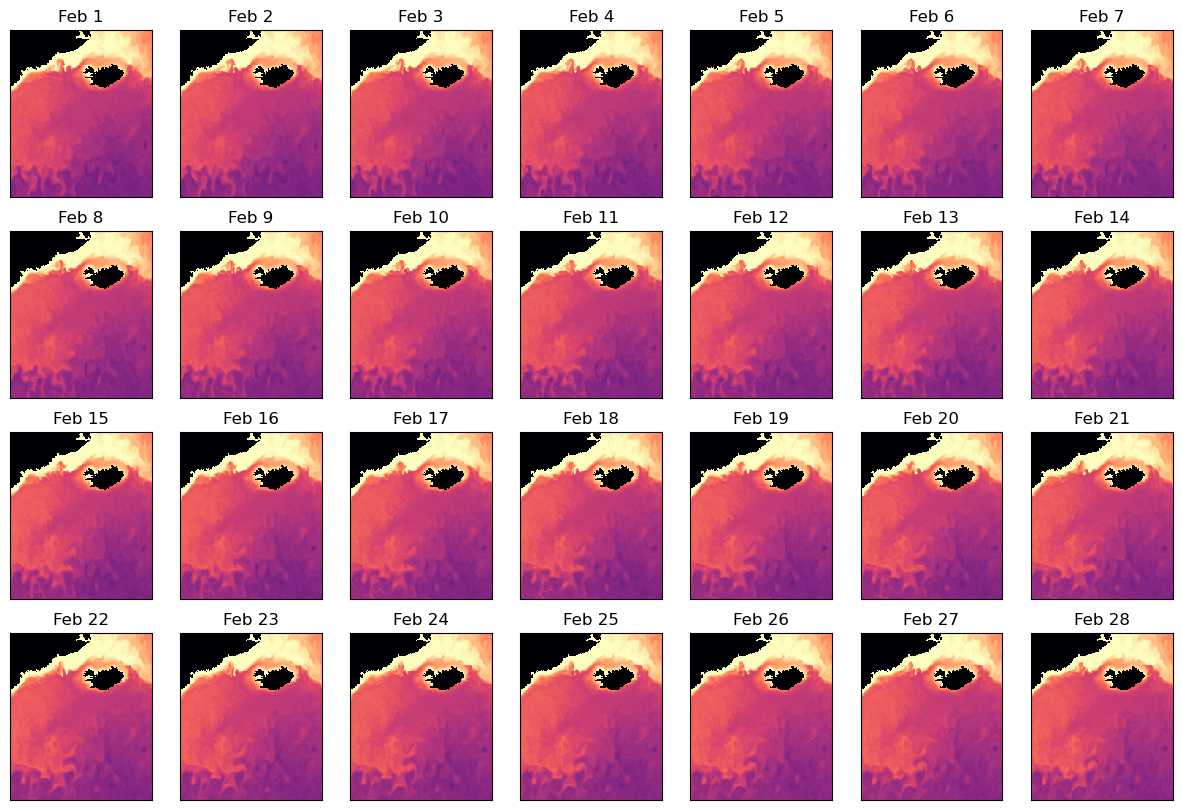

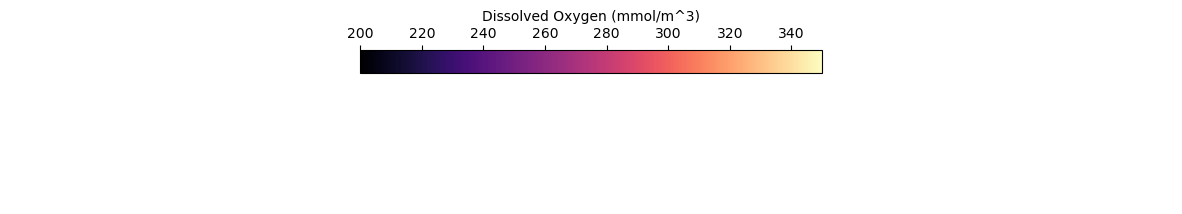

In [25]:
import xarray as xr
import matplotlib.pyplot as plt
# Open output dataset
feb_bgc_ds= xr.open_dataset("output/iceland_parent_bgc.20120201120000.nc")
surface_oxygen_feb =feb_bgc_ds["O2"].isel(s_rho=-1)

# Set up figure
fig,ax=plt.subplots(4,7)
fig.set_size_inches(15,10)

# Add panels for different days of output
for i in range(28):
    a = ax.reshape(-1)[i]
    p=surface_oxygen_feb.isel(time=i).plot(ax=a,add_colorbar=False,vmin=200,vmax=350,cmap="magma")
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel("")
    a.set_ylabel("")
    a.set_title(f"Feb {i+1}")

# Add a shared colorbar
fig2,ax2=plt.subplots()
cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=f"{surface_oxygen_feb.long_name} ({surface_oxygen_feb.units})")
fig2.set_size_inches(15,2)
ax2.set_axis_off()



Note that `roms-tools` also provides functionality for analyzing and regridding output. More details can be found in the `roms-tools` [documentation.](https://roms-tools.readthedocs.io/en/latest/reading_roms_output.html)

## Summary
In this tutorial, we:
- generated input data
- pre-processed the input data
- configured and compiled ROMS
- ran the model
- post-processed output data
- visualized a selected output

... for the parent domain of a two-domain nested regional ocean simulation with biogeochemistry. As part of the process, we defined the child domain and configured the parent simulation to produce boundary forcing files for it.

In the next tutorial, we will prepare and run the nested child simulation.